In [75]:
# import necessary libraries

#-------------- Python Libraries ------------------
import numpy as np # For linear algebra and numerical operations
import pandas as pd # For data processing and reading CSV files
import matplotlib.pyplot as plt # For basic visualizations
import seaborn as sns # For more appealing visualizations
import os
import scipy.stats as stats

#-------------- Scikit Learn ----------------------
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    log_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

#-------------- XGBoost ----------------------------
import xgboost as xgb

#-------------- Optuna -----------------------------
import optuna as opt

#-------------- Keras ------------------------------
from tensorflow.keras import models
from tensorflow.keras.layers import Dense


# set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("Libraries imported successfully!")

Libraries imported successfully!


In [76]:
# load the dataset
current_path = os.getcwd()

dataset_df = pd.read_csv(f"{current_path}/training.csv")

1. Data inspection: after inspecting its format and shape, the dataset is going to be split into features (X_data) and labels (y_data), and the distribution of lables is going to be analysed. After that, the format and shape of X_data and y_data is also going to be inspected.

In [77]:
# display the first 5 rows of the dataset
print("Dataset Head:")
display(dataset_df.head())

print("\nData loaded successfully")

Dataset Head:


,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653,s
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,2.233584,b
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,2.347389,b
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,5.446378,b
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,6.245333,b



Data loaded successfully


In [78]:
# split the dataset in features and labels, remove weights 
X_data = dataset_df.drop(columns=["EventId", "Weight", "Label"])
y_data = dataset_df["Label"]

In [79]:
print(f"Features shape: {X_data.shape}")
X_data.info()

Features shape: (250000, 30)
<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   DER_mass_MMC                 250000 non-null  float64
 1   DER_mass_transverse_met_lep  250000 non-null  float64
 2   DER_mass_vis                 250000 non-null  float64
 3   DER_pt_h                     250000 non-null  float64
 4   DER_deltaeta_jet_jet         250000 non-null  float64
 5   DER_mass_jet_jet             250000 non-null  float64
 6   DER_prodeta_jet_jet          250000 non-null  float64
 7   DER_deltar_tau_lep           250000 non-null  float64
 8   DER_pt_tot                   250000 non-null  float64
 9   DER_sum_pt                   250000 non-null  float64
 10  DER_pt_ratio_lep_tau         250000 non-null  float64
 11  DER_met_phi_centrality       250000 non-null  float64
 12  DER_lep_eta_centrality       250000 non-

In [80]:
print(f"Labels shape: {y_data.shape}")
y_data.info()

Labels shape: (250000,)
<class 'pandas.Series'>
RangeIndex: 250000 entries, 0 to 249999
Series name: Label
Non-Null Count   Dtype
--------------   -----
250000 non-null  str  
dtypes: str(1)
memory usage: 1.9 MB


In [81]:
print("\nDataset Features Description:")
display(X_data.describe())


Dataset Features Description:


,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,...,PRI_met_phi,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,...,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,-49.023079,49.239819,81.181982,57.895962,-708.420675,-601.237051,-709.356603,2.373100,18.917332,158.432217,...,-0.010119,209.797178,0.979176,-348.329567,-399.254314,-399.259788,-692.381204,-709.121609,-709.118631,73.064591
std,406.345647,35.344886,40.828691,63.655682,454.480565,657.972302,453.019877,0.782911,22.273494,115.706115,...,1.812223,126.499506,0.977426,532.962789,489.338286,489.333883,479.875496,453.384624,453.389017,98.015662
min,-999.000000,0.000000,6.329000,0.000000,-999.000000,-999.000000,-999.000000,0.208000,0.000000,46.104000,...,-3.142000,13.678000,0.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,0.000000
25%,78.100750,19.241000,59.388750,14.068750,-999.000000,-999.000000,-999.000000,1.810000,2.841000,77.550000,...,-1.575000,123.017500,0.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-0.000000
50%,105.012000,46.524000,73.752000,38.467500,-999.000000,-999.000000,-999.000000,2.491500,12.315500,120.664500,...,-0.024000,179.739000,1.000000,38.960000,-1.872000,-2.093000,-999.000000,-999.000000,-999.000000,40.512500
75%,130.606250,73.598000,92.259000,79.169000,0.490000,83.446000,-4.593000,2.961000,27.591000,200.478250,...,1.561000,263.379250,2.000000,75.349000,0.433000,0.503000,33.703000,-2.457000,-2.275000,109.933750
max,1192.026000,690.075000,1349.351000,2834.999000,8.503000,4974.979000,16.690000,5.684000,2834.999000,1852.462000,...,3.142000,2003.976000,3.000000,1120.573000,4.499000,3.141000,721.456000,4.500000,3.142000,1633.433000


In [82]:
# analyse label distribution
print("\nTarget Label Distribution:")
print(y_data.value_counts())


Target Label Distribution:
Label
b    164333
s     85667
Name: count, dtype: int64


2. Explorative Data Analysis: In this part, the distribution of three sample features ("DER_mass_MMC", "PRI_tau_eta", "DER_mass_jet_jet") in the training set is goign to be plotted. At first, this is done taking into consideration all the values for that feature; secondly, singal events are separated from background events and, for each sample feature, the distribution is plotted separately. The information on the ditribution of the features is going to be used to decide if nan values should be filled with mean or median of a given feature.

In [83]:
# split the training set into signal events and background events
signal = X_data[y_data == "s"]
background = X_data[y_data == "b"]

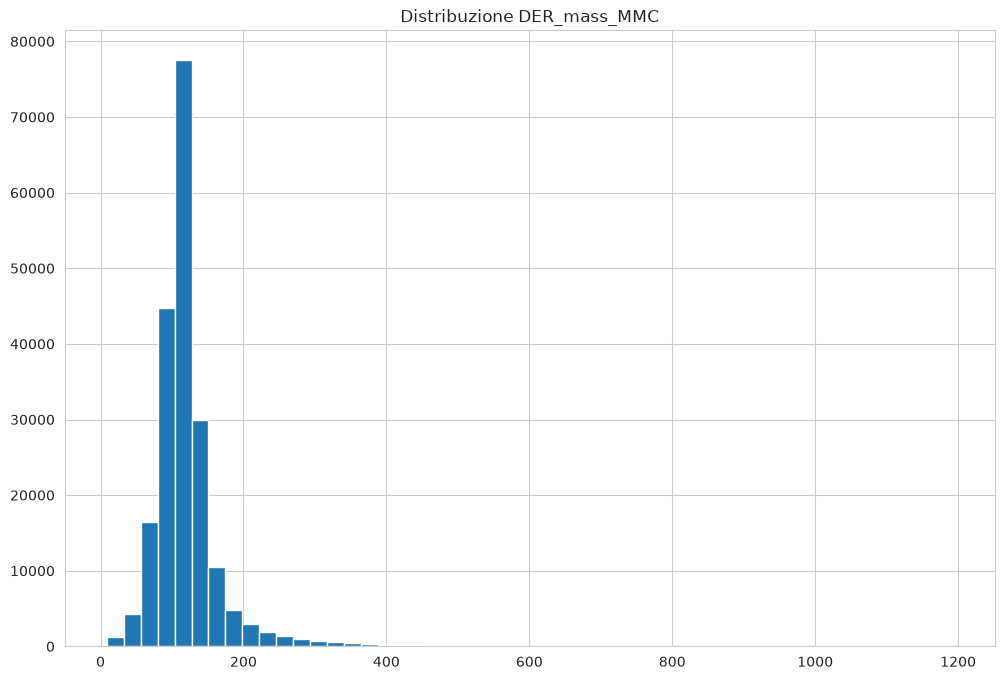

In [84]:
X_tr["DER_mass_MMC"].hist(bins=50)
plt.title("Distribuzione DER_mass_MMC")
plt.show()

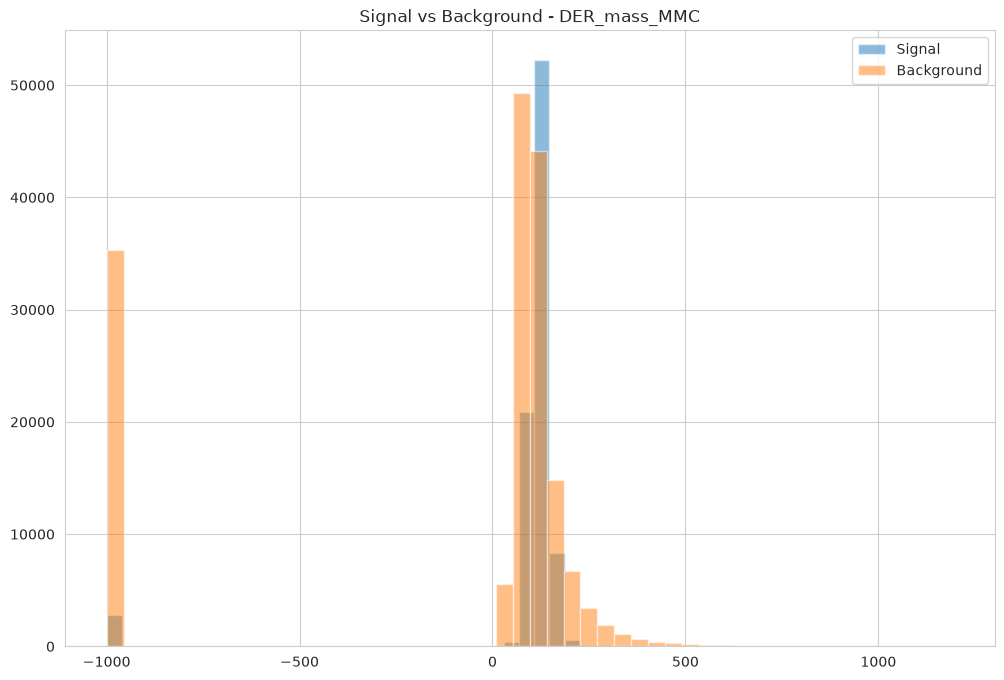

In [85]:
plt.hist(signal["DER_mass_MMC"], bins=50, alpha=0.5, label="Signal")
plt.hist(background["DER_mass_MMC"], bins=50, alpha=0.5, label="Background")

plt.legend()
plt.title("Signal vs Background - DER_mass_MMC")
plt.show()

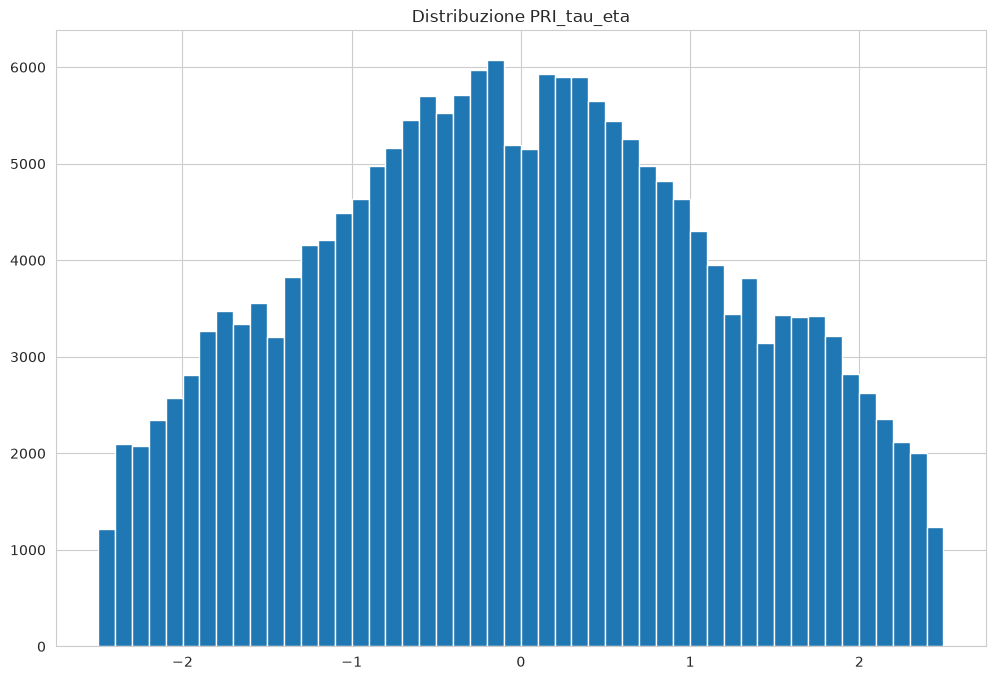

In [86]:
X_tr["PRI_tau_eta"].hist(bins=50)
plt.title("Distribuzione PRI_tau_eta")
plt.show()

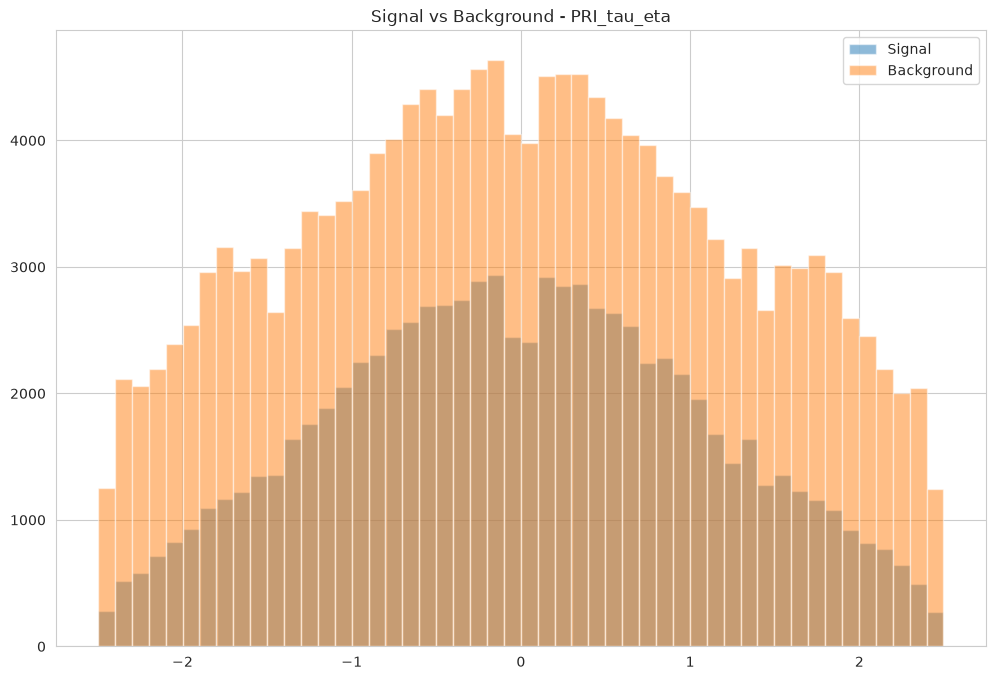

In [87]:
plt.hist(signal["PRI_tau_eta"], bins=50, alpha=0.5, label="Signal")
plt.hist(background["PRI_tau_eta"], bins=50, alpha=0.5, label="Background")

plt.legend()
plt.title("Signal vs Background - PRI_tau_eta")
plt.show()

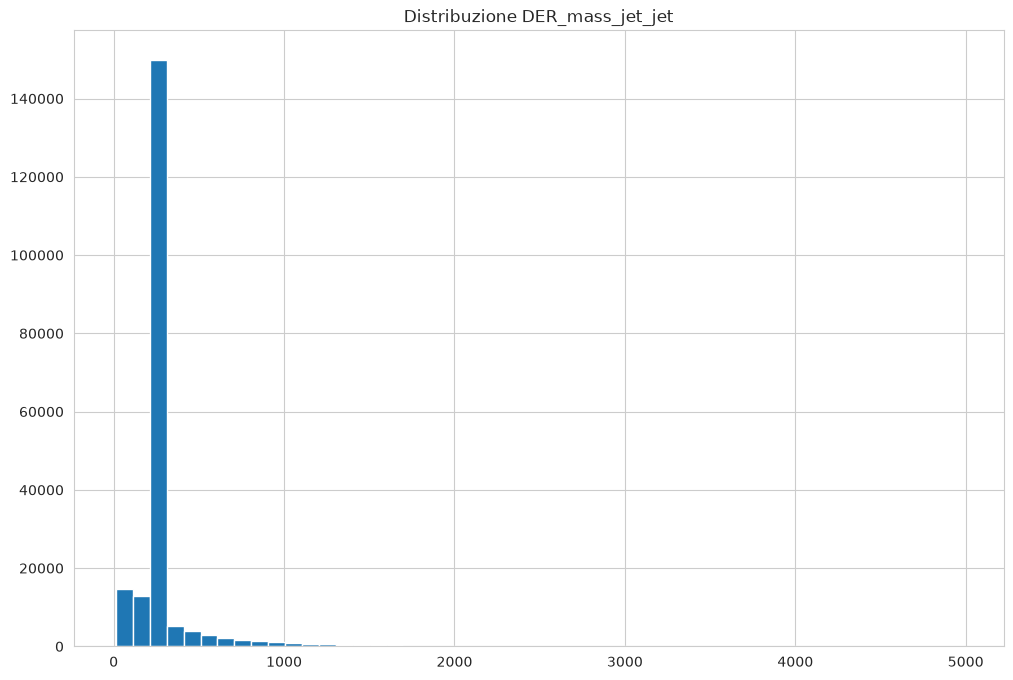

In [88]:
X_tr["DER_mass_jet_jet"].hist(bins=50)
plt.title("Distribuzione DER_mass_jet_jet")
plt.show()

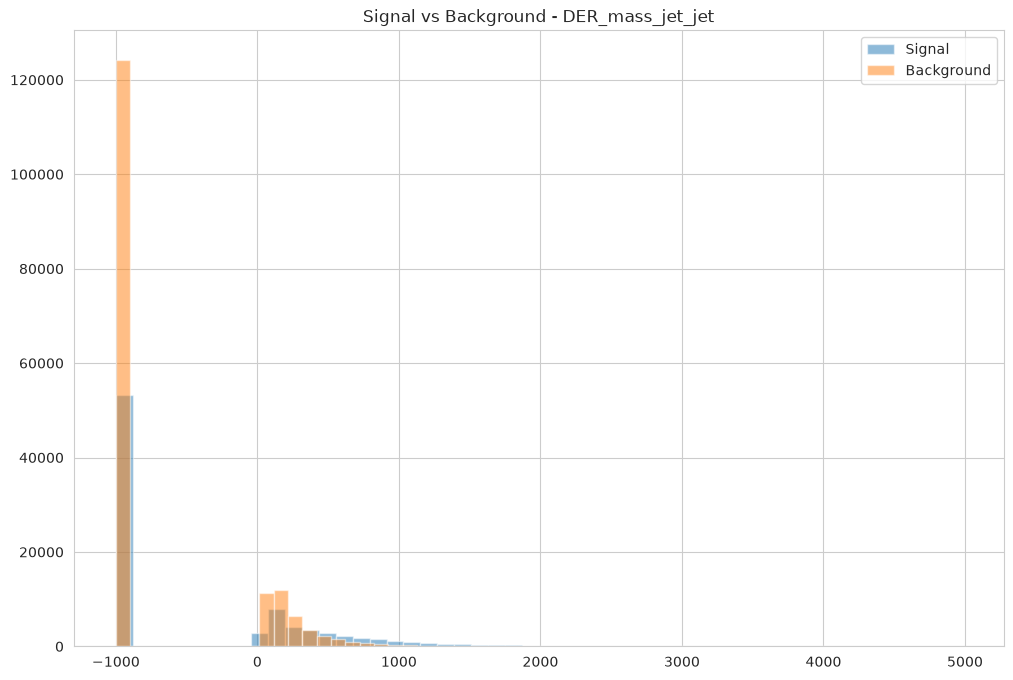

In [89]:
plt.hist(signal["DER_mass_jet_jet"], bins=50, alpha=0.5, label="Signal")
plt.hist(background["DER_mass_jet_jet"], bins=50, alpha=0.5, label="Background")

plt.legend()
plt.title("Signal vs Background - DER_mass_jet_jet")
plt.show()

3. Data Preprocessing: the dataset format is going to be preprocessed so that it can be prepared for the training part according to the project purposes. In particular, labels "b" and "s" are going to be converted into integers "0" and "1", respectively. To add to this, -999.0 values are going to be handled by replacing them with "nan", so that they do not affect the statistics for that column. After splitting the dataset into a training set and a test set, for each feature, "nan" values are going to be filled with the corresponding median. 

In [90]:
# convert string-type lables into integers 
y_data.replace("b", 0, inplace=True)
y_data.replace("s", 1, inplace=True)
print(y_data)

0         1
1         0
2         0
3         0
4         0
         ..
249995    0
249996    0
249997    1
249998    0
249999    0
Name: Label, Length: 250000, dtype: object


In [91]:
# replace -999.0 with nan
X_data.replace(-999.0, np.nan, inplace=True)

# check the amount of missing values
missing_percent = X_data.isna().mean() * 100

# sort them descendingly
missing_percent = missing_percent.sort_values(ascending=False)

print(missing_percent)

DER_deltaeta_jet_jet           70.9828
DER_mass_jet_jet               70.9828
DER_lep_eta_centrality         70.9828
DER_prodeta_jet_jet            70.9828
PRI_jet_subleading_pt          70.9828
PRI_jet_subleading_phi         70.9828
PRI_jet_subleading_eta         70.9828
PRI_jet_leading_pt             39.9652
PRI_jet_leading_eta            39.9652
PRI_jet_leading_phi            39.9652
DER_mass_MMC                   15.2456
DER_pt_h                        0.0000
DER_mass_vis                    0.0000
DER_mass_transverse_met_lep     0.0000
PRI_tau_pt                      0.0000
DER_met_phi_centrality          0.0000
DER_pt_ratio_lep_tau            0.0000
DER_sum_pt                      0.0000
DER_deltar_tau_lep              0.0000
DER_pt_tot                      0.0000
PRI_tau_eta                     0.0000
PRI_tau_phi                     0.0000
PRI_met_sumet                   0.0000
PRI_met_phi                     0.0000
PRI_met                         0.0000
PRI_lep_phi              

In [92]:
# split the dataset into traing and test set
X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y_data,
    stratify=y_data,    
    test_size=0.2,
    random_state=42
)

In [93]:
# fill the missing values with median
X_tr = X_train.fillna(X_train.median(numeric_only=True))
X_test = X_test.fillna(X_test.median(numeric_only=True))


Note that the missing values for training set and test set were filled separately in order to avoid contaminating the training set with information coming from the test set.

4. Definition of Machine Learning Models: a linear SGD classifier, a decision-tree-based XGBoost classifier and a simple Deep Neural Network are going to be trained on the training set, which needs to be scaled to imporve the performance of the SGD Classifier and of the DNN.

In [94]:
# scale the dataset first; so that features lies between 0 and 1
scaler1 = StandardScaler()
X_train_scaled = scaler1.fit_transform(X_tr)
X_test_scaled = scaler1.fit_transform(X_test)

In [95]:
%%time

#Model 1: linear SGDC classifier
sgd_clf = SGDClassifier(loss="log_loss", max_iter=1000, tol=1e-3, random_state=42)
sgd_clf.fit(X_train_scaled, y_train.astype('int'))

CPU times: user 1.33 s, sys: 32.3 ms, total: 1.37 s
Wall time: 1.37 s


,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'log_loss'
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; onl

In [96]:
%%time
xgb_model_1 = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    device="cuda", #force GPU usage if possible
    tree_method="hist",
    n_estimators=300,
    n_jobs=-1
)

xgb_model_1.fit(
    X_tr,
    y_train
)


/home/feenaldi/SCNSN/Project/SCNSN_Project-env/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:32:05] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/home/feenaldi/SCNSN/Project/SCNSN_Project-env/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:32:05] WARNING: /__w/xgboost/xgboost/src/context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


CPU times: user 43.9 s, sys: 676 ms, total: 44.6 s
Wall time: 12.6 s


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [97]:
# Model 3: DNN
dnn = models.Sequential([
    Dense(64, activation='relu', input_shape=(X_tr.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

/home/feenaldi/SCNSN/Project/SCNSN_Project-env/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [98]:
dnn.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy', 'AUC'])

In [99]:
%%time
history_callback = dnn.fit(X_train_scaled, y_train.astype('int'), epochs=10, batch_size=128, validation_split=0.2)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - AUC: 0.8801 - accuracy: 0.8125 - loss: 0.4096 - val_AUC: 0.8970 - val_accuracy: 0.8316 - val_loss: 0.3790
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - AUC: 0.9017 - accuracy: 0.8333 - loss: 0.3733 - val_AUC: 0.9003 - val_accuracy: 0.8345 - val_loss: 0.3725
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - AUC: 0.9050 - accuracy: 0.8366 - loss: 0.3668 - val_AUC: 0.9017 - val_accuracy: 0.8345 - val_loss: 0.3703
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - AUC: 0.9068 - accuracy: 0.8379 - loss: 0.3630 - val_AUC: 0.9040 - val_accuracy: 0.8385 - val_loss: 0.3657
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - AUC: 0.9080 - accuracy: 0.8394 - loss: 0.3605 - val_AUC: 0.9049 - val_accuracy: 0.8392 - val_loss: 0.3648
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - AUC: 0.9091 - accuracy: 0.8408 - loss: 0.3583 - val_AUC: 0.9045 - val_accuracy: 0.8363 - val_loss: 0.3691
Epoch 7/10
1250/1250 ━━━━━━

<Axes: >

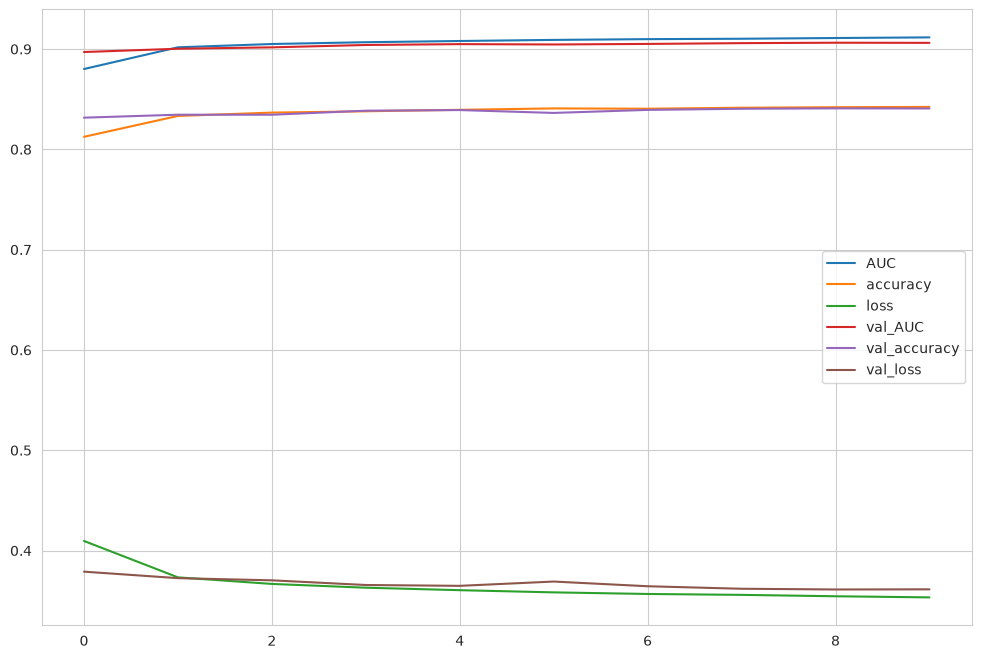

In [100]:
pd.DataFrame(history_callback.history).plot()

5. Model evaluation and comparison: the performance of the three models is going to be evaluated according to the following metrics: accuracy, precision, recall, F1-score, and ROC-AUC.

In [101]:
# evaluation function

def evaluate_model(model, X, y, name="Model"):

    # predictions
    y_pred = model.predict(X)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X)
    else:
        # DNN case (Keras)
        y_score = model.predict(X).ravel()

    # --- predictions (class labels) ---
    if hasattr(model, "predict_proba") or hasattr(model, "decision_function"):
        y_pred = (y_score > 0.5).astype(int)
    else:
        y_pred = (y_score > 0.5).astype(int)

    # metrics
    metrics = {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1-score": f1_score(y, y_pred),
        "ROC-AUC": roc_auc_score(y, y_score)
    }

    print(f"\n=== {name} ===")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

    current_path = os.getcwd()
    os.makedirs(f"{current_path}/results/{name}", exist_ok=True)
           

    # ROC curve
    fpr, tpr, _ = roc_curve(y, y_score)

    plt.figure()
    plt.plot(fpr, tpr, label=f"{name} (AUC = {metrics['ROC-AUC']:.3f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.savefig(f"{current_path}/results/{name}/AUC_{name}.pdf", bbox_inches='tight')

    plt.show()

    # --- Confusion matrix ---
    ConfusionMatrixDisplay.from_predictions(y, y_pred)
    plt.title(f"Confusion Matrix - {name}")
    plt.savefig(f"{current_path}/results/{name}/CM_{name}.pdf", bbox_inches='tight')
    plt.show()

    return metrics



=== SGD ===
Accuracy: 0.7520
Precision: 0.6676
Recall: 0.5499
F1-score: 0.6031
ROC-AUC: 0.8098


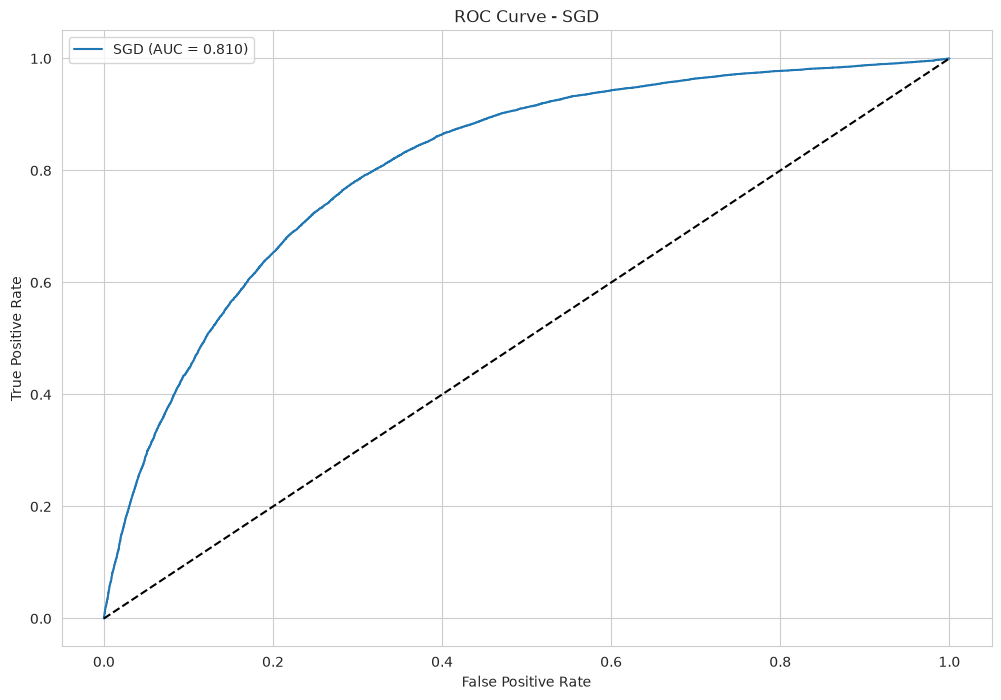

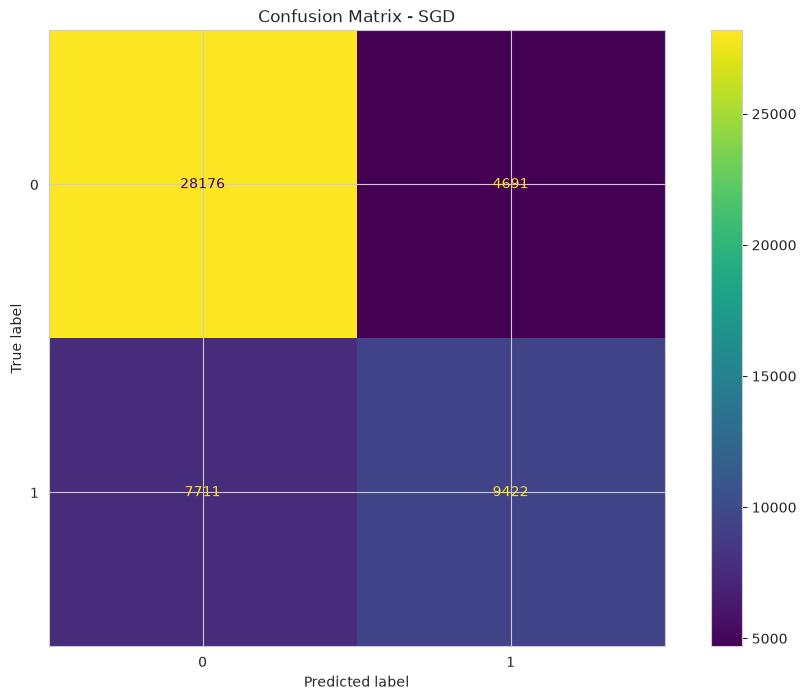

In [102]:
# SGDC Classifier
sgd_metrics = evaluate_model(
    sgd_clf,
    X_test_scaled,
    y_test.astype('int'),
    name="SGD"
)


=== XGBoost ===
Accuracy: 0.8367
Precision: 0.7892
Recall: 0.7144
F1-score: 0.7499
ROC-AUC: 0.9033


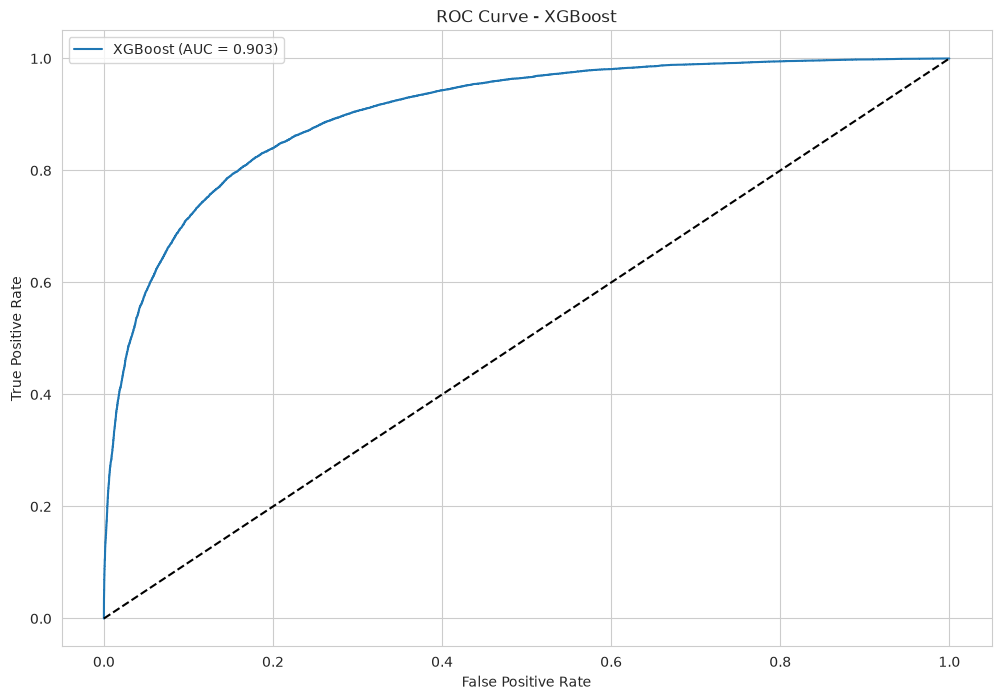

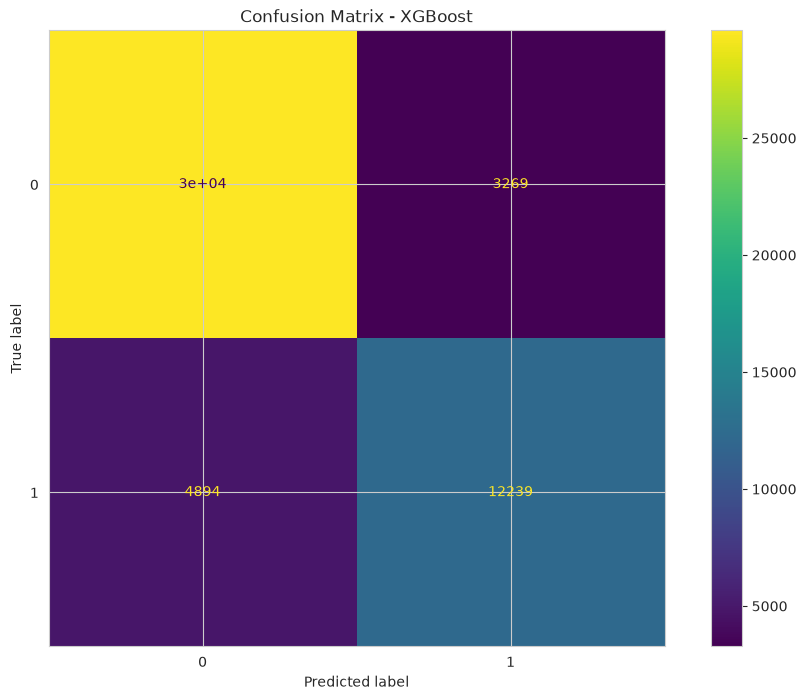

In [103]:
# Xgboost mdel
xgb_metrics = evaluate_model(
    xgb_model_1,
    X_test,
    y_test.astype('int'),
    name="XGBoost"
)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

=== DNN ===
Accuracy: 0.8376
Precision: 0.8021
Recall: 0.6984
F1-score: 0.7467
ROC-AUC: 0.9069


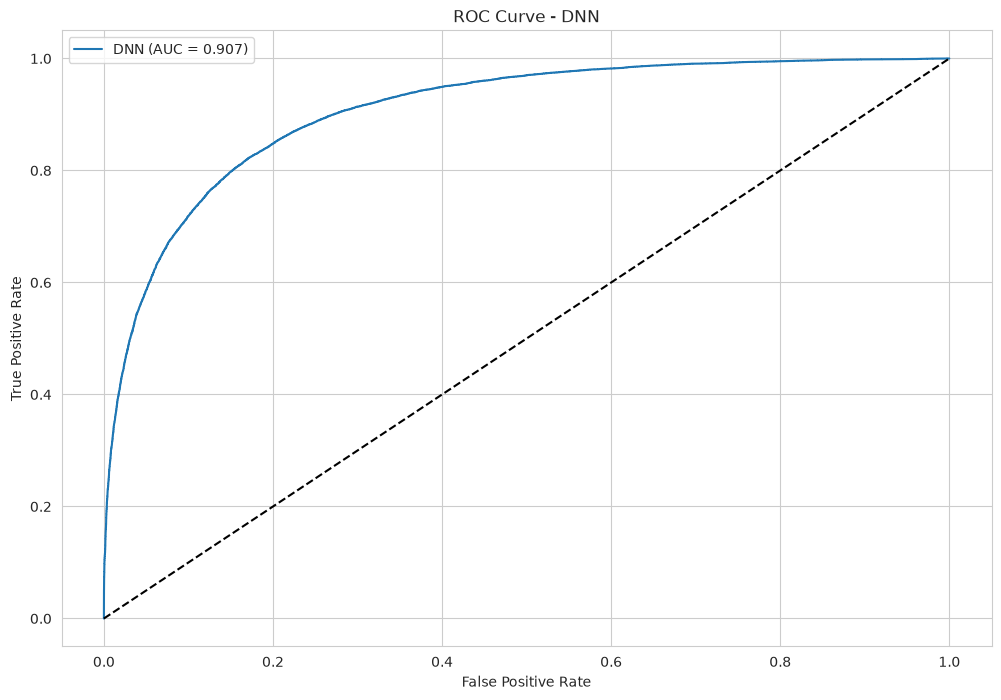

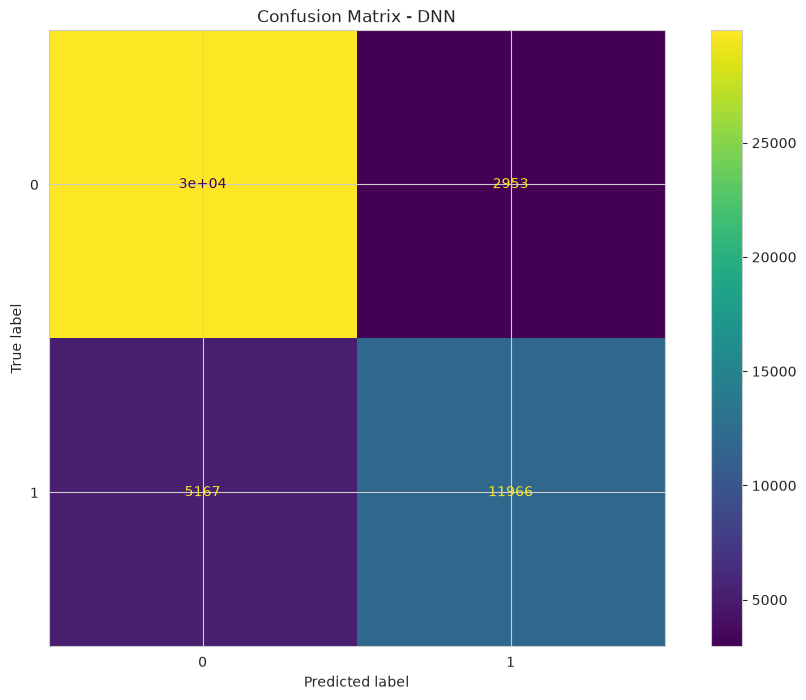

In [104]:
# DNN
dnn_metrics = evaluate_model(
    dnn,
    X_test_scaled,
    y_test.astype('int'),
    name="DNN"
)

6. Possible improvements for XGBoost Classifier: three XGBoost Classifiers are going to be built, introducing variatios with respect to the first implementation of the first classifier. In particular, xgb_model_1 is going to be trained on a dataset that was not imputed (in which np.nan values are not replaced)m xgb_model_2 is going to be trained on a dataset that contains only the top 10 features for mutual information, while xgb_model_3 is going to undergo hyperparameter tuning before being trained on te original dataset.

In [105]:
%%time
# Model 1 -- do not replace np.nan values

xgb_model_1 = xgb.XGBClassifier(
    tree_method='hist',  # Algoritmo ottimizzato ad albero
    device='cuda',       # Forza l'utilizzo della GPU
    n_estimators=100
)

xgb_model_1.fit(X_train, y_train)


/home/feenaldi/SCNSN/Project/SCNSN_Project-env/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:33:32] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/home/feenaldi/SCNSN/Project/SCNSN_Project-env/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:33:32] WARNING: /__w/xgboost/xgboost/src/context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


CPU times: user 20.8 s, sys: 520 ms, total: 21.3 s
Wall time: 6.01 s


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None



=== XGBoost_1 ===
Accuracy: 0.8280
Precision: 0.7977
Recall: 0.6671
F1-score: 0.7266
ROC-AUC: 0.8913


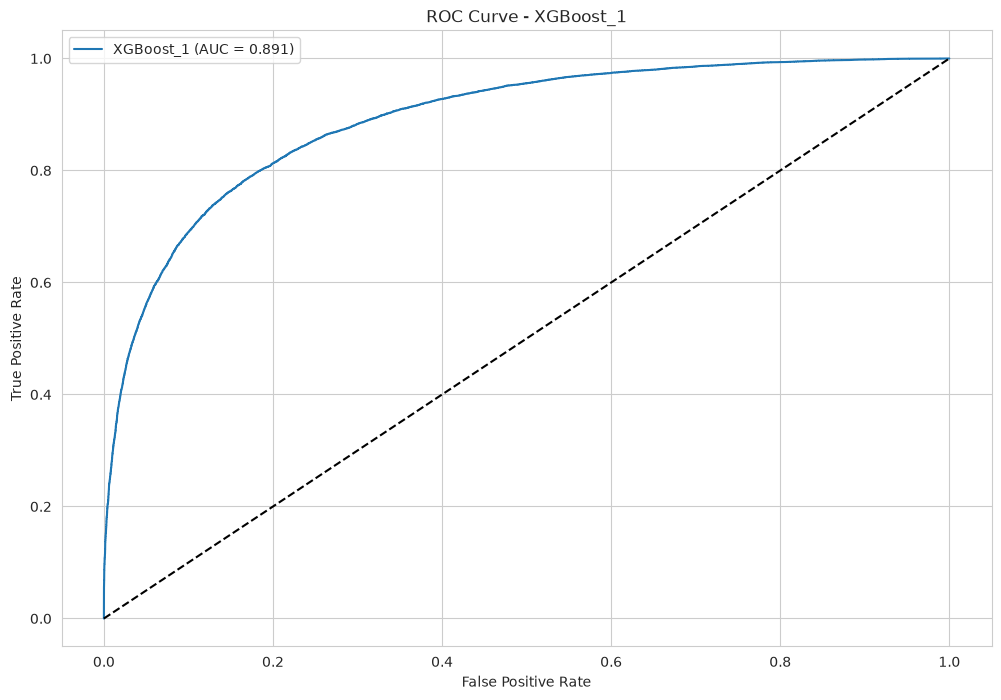

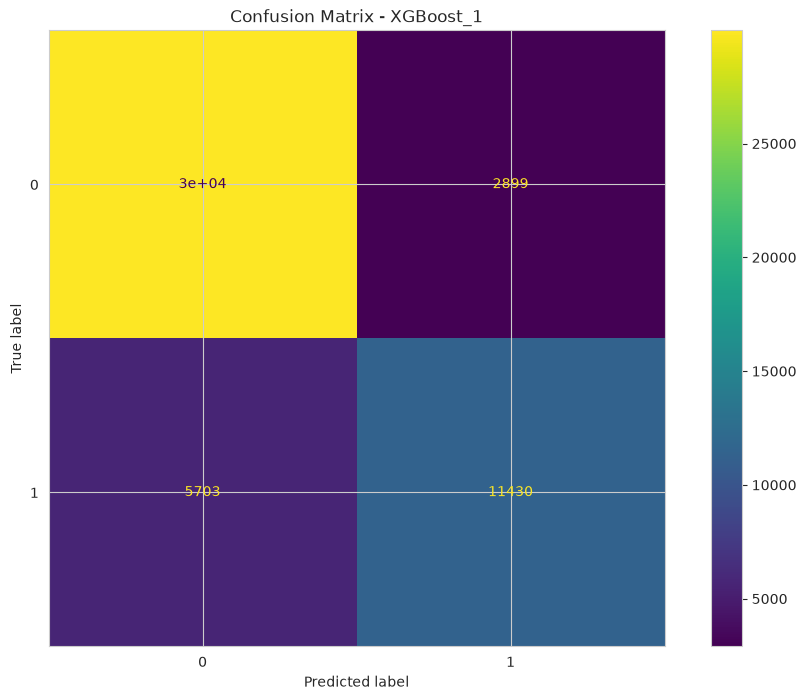

In [119]:
xgb_metrics_1 = evaluate_model(
    xgb_model_1,
    X_test,
    y_test.astype("int"),
    name="XGBoost_1"
)

In [107]:
X_sample = X_tr.sample(n=20000, random_state=42)
y_sample = y_train.loc[X_sample.index]

# mutual information
print("Mutual Information score (relazioni...")
mi_scores = mutual_info_classif(X_sample, y_sample.astype("int"), random_state=42)

# show results
df_mi = pd.DataFrame({
    'Feature': X_tr.columns,
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)

print("\n in order:")
print(df_mi.head(10))

#top k feature selection
non_linear_selector = SelectKBest(score_func=mutual_info_classif, k=10)

# fit
non_linear_selector.fit(X_sample, y_sample.astype("int"))

# keep only selected feature
X_tr_2 = non_linear_selector.transform(X_tr)
X_test_2 = non_linear_selector.transform(X_test)

# show selected feature
saved_feature = X_tr.columns[non_linear_selector.get_support()]
print(f"\nFeature selezionate ({len(saved_feature)}): {list(saved_feature)}")


Mutual Information score (relazioni...

 in order:
                        Feature  MI_Score
0                  DER_mass_MMC  0.143829
1   DER_mass_transverse_met_lep  0.086420
2                  DER_mass_vis  0.076573
13                   PRI_tau_pt  0.053837
11       DER_met_phi_centrality  0.049025
10         DER_pt_ratio_lep_tau  0.040668
5              DER_mass_jet_jet  0.035482
4          DER_deltaeta_jet_jet  0.033214
12       DER_lep_eta_centrality  0.031965
6           DER_prodeta_jet_jet  0.027204

Feature selezionate (10): ['DER_mass_MMC', 'DER_mass_transverse_met_lep', 'DER_mass_vis', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet', 'DER_prodeta_jet_jet', 'DER_pt_ratio_lep_tau', 'DER_met_phi_centrality', 'DER_lep_eta_centrality', 'PRI_tau_pt']


In [108]:
%%time
# Model 2 -- select top ten features
xgb_model_2 = xgb.XGBClassifier(
    tree_method='hist',  # Algoritmo ottimizzato ad albero
    device='cuda',       # Forza l'utilizzo della GPU
    n_estimators=100
)

xgb_model_2.fit(X_tr_2, y_train)

/home/feenaldi/SCNSN/Project/SCNSN_Project-env/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:33:52] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/home/feenaldi/SCNSN/Project/SCNSN_Project-env/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:33:52] WARNING: /__w/xgboost/xgboost/src/context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


CPU times: user 8.29 s, sys: 93.6 ms, total: 8.38 s
Wall time: 2.49 s


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None



=== XGBoost_2 ===
Accuracy: 0.8239
Precision: 0.7998
Recall: 0.6482
F1-score: 0.7161
ROC-AUC: 0.8923


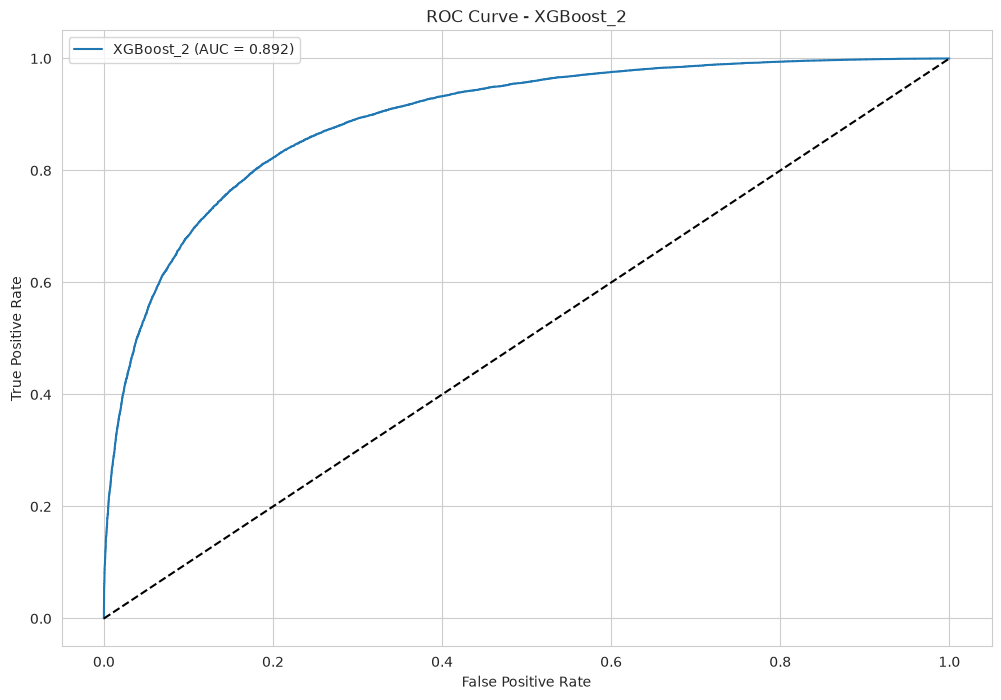

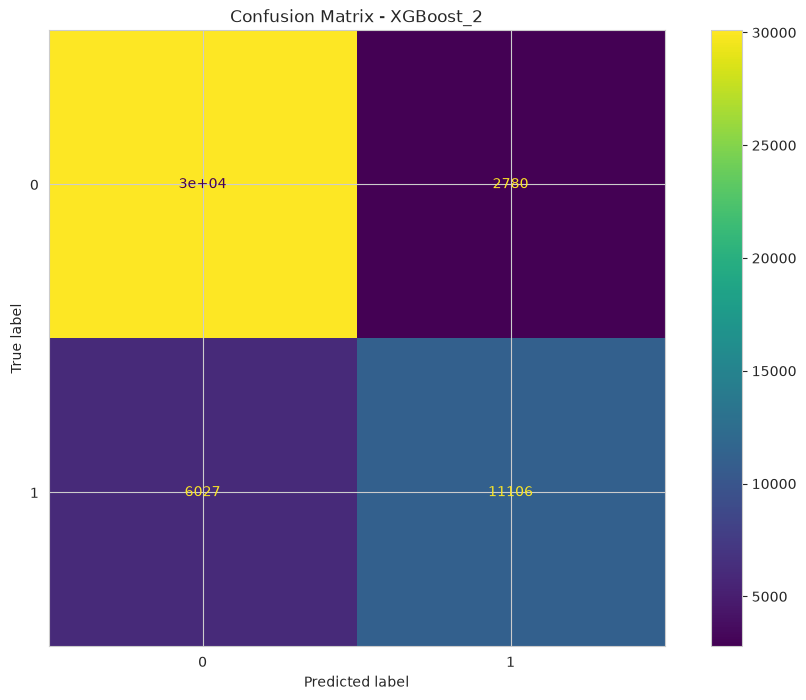

In [118]:
xgb_metrics_2 = evaluate_model(
    xgb_model_2,
    X_test_2,
    y_test.astype("int"),
    name="XGBoost_2"
)

In [ ]:
%%time
# Model 3 -- Hyperparamter tuning

# define the hyperparameter distribution
param_dist = {
    "max_depth": stats.randint(3, 10),
    "learning_rate": stats.uniform(0.01, 0.1),
    "subsample": stats.uniform(0.5, 0.5),
    "n_estimators":stats.randint(50, 200)
}

xgb_model_3 = xgb.XGBClassifier()

random_search = RandomizedSearchCV(xgb_model_3, param_distributions=param_dist, n_iter=10, cv=5, scoring="roc_auc")
random_search.fit(X_tr, y_train)

best_par = random_search.best_params_
print("Best set of hyperparameters: ", random_search.best_params_)
print("Best score: ", random_search.best_score_)


/home/feenaldi/SCNSN/Project/SCNSN_Project-env/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/feenaldi/SCNSN/Project/SCNSN_Project-env/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/home/feenaldi/SCNSN/Project/SCNSN_Project-env/lib/python3.13/site-packages/sklearn/utils/validation.py", line 80, in inner_f
    return f(*args, **kwargs)
  File "/home/feenaldi/SCNSN/Project/SCNSN_Project-env/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 322, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/feenaldi/SCNSN/Project/SCNSN_Projec

Best set of hyperparameters:  {'learning_rate': np.float64(0.10614871314484856), 'max_depth': 6, 'n_estimators': 166, 'subsample': np.float64(0.6046679945262374)}
Best score:  nan
CPU times: user 28min 36s, sys: 58.4 s, total: 29min 35s
Wall time: 8min 47s


In [115]:
xgb_tuned = xgb.XGBClassifier(
    **best_par,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    device="cpu",
    n_jobs=-1
)

In [116]:
xgb_tuned.fit(
    X_tr,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cpu'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None



=== XGBoost_tuned ===
Accuracy: 0.8410
Precision: 0.7974
Recall: 0.7186
F1-score: 0.7559
ROC-AUC: 0.9087


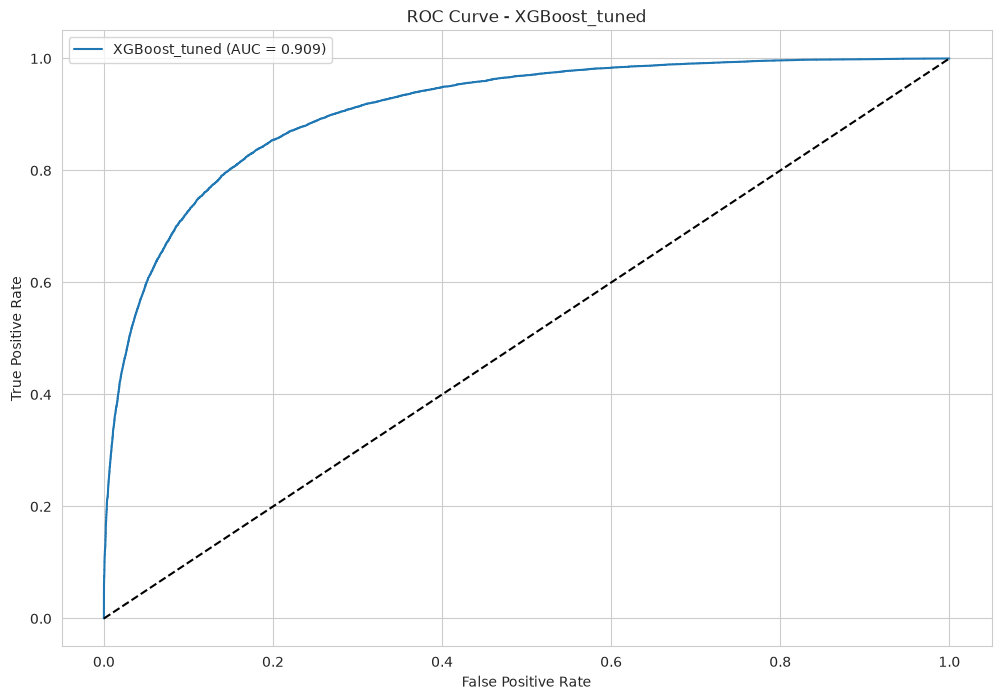

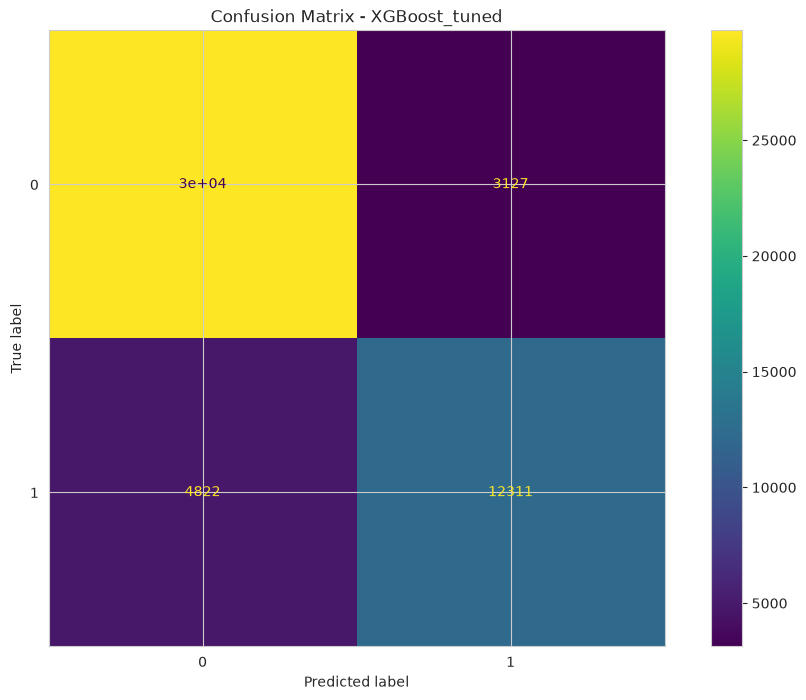

In [117]:
xgb_tuned_metric = evaluate_model(
    xgb_tuned,
    X_test,
    y_test.astype("int"),
    name="XGBoost_tuned"
)

8. Results Summary: Create two .csv files, one for the comparison of the three different models; one for the cmomparison of the different implementation of the XGBoost classifier. Write them to a file.

In [120]:
# create the results folder 
os.makedirs(f"{current_path}/results/", exist_ok=True)

In [121]:
# comparison between SGD, XGBoost and DNN
results_1 = [sgd_metrics, xgb_metrics, dnn_metrics]
df_1 = pd.DataFrame(results_1, index=["SGDC", "XGBoost", "DNN"]).T

df_1.to_csv(f"{current_path}/results/benchmark_ML.csv")
print("File 'benchmark_ML.csv' salvato con successo!")

File 'benchmark_ML.csv' salvato con successo!


In [122]:
# comparison between different implementation of XGBOOST
results_2 = [xgb_metrics, xgb_metrics_2, xgb_metrics_3, xgb_tuned_metric]
df_2 = pd.DataFrame(results_2, index=["Model 1", "Model 2", "Model 3", "Tuning"]).T

df_2.to_csv(f"{current_path}/results/benchmark_XGB.csv")
print("File 'benchmark_XGB.csv' salvato con successo!")

File 'benchmark_XGB.csv' salvato con successo!
